<a href="https://colab.research.google.com/github/AishahTemitopeMustapha/SuperstoreDataset/blob/master/Copy_of_COMPREHENSIVE_SUPERSTORE_SALES_ANALYSIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![My Image](C:/Users/USER/Downloads/josh-withers-5W3JkWpA_wU-unsplash.jpg)


![My Image](https://images.unsplash.com/photo-1574901200090-ca061722bdb9?q=80&w=1470&auto=format&fit=crop)


# COMPREHENSIVE SUPERSTORE SALES ANALYSIS: TRENDS, INSIGHTS, AND STRATEGIC RECOMMENDATIONS


## **INTRODUCTION**  

This analysis examines a retail superstore dataset containing **1,993 rows and 25 columns**, covering key metrics such as **Sales, Quantity Sold, Profit, Order Date, Product Name, and Region**. The objective is to identify trends and insights that can support data-driven decision-making.  

## **Key Steps in the Analysis**  

### 🔹 **Data Cleaning:**  
- Removed duplicate records to maintain data integrity.  
- Converted **Order Date** and **Ship Date** to datetime format for accurate time-based analysis.  
- Ensured **Sales** and **Quantity** were in numeric format for precise calculations.  

### 🔹 **Feature Engineering:**  
- Extracted **Month** and **Year** from the Order Date to analyze trends over time.  

### 🔹 **Analysis Methods:**  
- Aggregated data to compute total sales, profit, and key performance metrics.  
- Used **line graphs** to analyze sales trends over time.  
- Applied **bar charts** to compare product categories, customer segments, and regional performance.  

By structuring and analyzing this dataset, we uncover key insights into **sales performance, profitability trends, and customer behavior**, enabling strategic recommendations for business growth. 🚀


In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


##### import libraries


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')



## DATA CLEANING AND PREPARATION

In [3]:
# ── Load from Google Drive ──────────────────────────────────────
sheet_id = '14hMboCJnIhbVQB6C7syJf3ijEkaYGZ9fRTVBqmnv3Tc'
gid = '488006774'
url = f'https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid}'
df = pd.read_csv(url)

df.drop_duplicates(inplace=True)
print("Shape:", df.shape)
print(df.isnull().sum())

df["Order ID"]    = df["Order ID"].astype(str)
df["Product ID"]  = df["Product ID"].astype(str)
df["Customer ID"] = df["Customer ID"].astype(str)

df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d-%b-%y', errors='coerce')
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  format='%d-%b-%y', errors='coerce')

df["Sales"]    = pd.to_numeric(df["Sales"],    errors='coerce')
df["Quantity"] = pd.to_numeric(df["Quantity"], errors='coerce')
df["Profit"]   = pd.to_numeric(df["Profit"],   errors='coerce')
df["Discount"] = pd.to_numeric(df["Discount"], errors='coerce')

df["order Month"] = df["Order Date"].dt.month
df["order Year"]  = df["Order Date"].dt.year
df["order Day"]   = df["Order Date"].dt.day
df["ship Month"]  = df["Ship Date"].dt.month
df["ship Year"]   = df["Ship Date"].dt.year
df["ship Day"]    = df["Ship Date"].dt.day

# Discount brackets used across all pages
bins   = [-0.01, 0.0, 0.10, 0.20, 0.30, 0.40, 0.50, 1.0]
labels = ['0%', '1-10%', '11-20%', '21-30%', '31-40%', '41-50%', '51%+']
df['Discount Bracket'] = pd.cut(df['Discount'], bins=bins, labels=labels)

# Profit flag
df['Is Loss'] = df['Profit'] < 0

print("\nRegions:", df["Region"].unique())
print("Categories:", df["Category"].unique())
print("\nData loaded successfully ✅")
df.head()

Shape: (1993, 21)
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Regions: ['West' 'South' 'Central' 'East']
Categories: ['Office Supplies' 'Furniture' 'Technology']

Data loaded successfully ✅


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Discount,Profit,order Month,order Year,order Day,ship Month,ship Year,ship Day,Discount Bracket,Is Loss
0,7,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,0.0,1.9656,6,2014,9,6,2014,14,0%,False
1,10,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,0.0,34.4700,6,2014,9,6,2014,14,0%,False
2,172,CA-2014-118962,2014-08-05,2014-08-09,Standard Class,CS-12130,Chad Sievert,Consumer,United States,Los Angeles,...,0.0,9.8418,8,2014,5,8,2014,9,0%,False
3,173,CA-2014-118962,2014-08-05,2014-08-09,Standard Class,CS-12130,Chad Sievert,Consumer,United States,Los Angeles,...,0.0,53.2608,8,2014,5,8,2014,9,0%,False
4,1143,CA-2014-146969,2014-09-29,2014-10-03,Standard Class,AP-10915,Arthur Prichep,Consumer,United States,Los Angeles,...,0.0,2.8776,9,2014,29,10,2014,3,0%,False


### **Data Cleaning and Preparation: Explanation**  

1. **Loading the Data**  
   - The dataset is imported from a CSV file into a pandas DataFrame.  

2. **Removing Duplicates**  
   - Duplicate rows are removed to maintain data integrity and avoid redundant records.  

3. **Converting Data Types**  
   - The `Order Date` and `Ship Date` columns are converted to datetime format to enable time-based analysis.  
   - `Sales` and `Quantity` are converted to numeric data types to ensure accurate calculations.  

4. **Extracting Date Components for Trend Analysis**  
   - Additional columns (`order Month`, `order Year`, `order Day`) are created from the `Order Date` to facilitate monthly, yearly, and daily trend analysis.  
   - Similarly, `ship Month`, `ship Year`, and `ship Day` are extracted from the `Ship Date` to analyze shipping trends.  

With this cleaned and structured dataset, we can now proceed to analyzing sales performance and identifying key insights. 🚀


## ANALYSE SALES PERFORMANCE

In [4]:
# Calculate Total Sales, Total Quantity Sold, and Total Profit
total_sales = df['Sales'].sum()
total_quantity_sold = df['Quantity'].sum()
total_profit = df['Profit'].sum()

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Quantity Sold: {total_quantity_sold}")
print(f"Total Profit: ${total_profit:,.2f}")

# Identify the Top 5 Best-Selling Products by Total Sales
top_5_products = df.groupby('Product Name').agg({'Sales': 'sum'}).sort_values(by='Sales', ascending=False).head(5)
print("\nTop 5 Best-Selling Products by Total Sales:")
print(top_5_products)

# Identify the Bottom 5 Least-Selling Products by Total Sales
bottom_5_products = df.groupby('Product Name').agg({'Sales': 'sum'}).sort_values(by='Sales', ascending=True).head(5)
print("\nBottom 5 Least-Selling Products by Total Sales:")
print(bottom_5_products)

# Identify the Top 5 Best-Selling Products by Quantity Sold
top_5_products_quantity = df.groupby('Product Name').agg({'Quantity': 'sum'}).sort_values(by='Quantity', ascending=False).head(5)
print("\nTop 5 Best-Selling Products by Quantity Sold:")
print(top_5_products_quantity)

# Identify the Bottom 5 Least-Selling Products by Quantity Sold
bottom_5_products_quantity = df.groupby('Product Name').agg({'Quantity': 'sum'}).sort_values(by='Quantity', ascending=True).head(5)
print("\nBottom 5 Least-Selling Products by Quantity Sold:")
print(bottom_5_products_quantity)

# Determine the Region with the Highest Revenue
region_revenue = df.groupby('Region').agg({'Sales': 'sum'}).sort_values(by='Sales', ascending=False).head(5)
print("\nRegion with the Highest Revenue:")
print(region_revenue)

# Determine the Region with the Highest Profit
region_profit = df.groupby('Region').agg({'Profit': 'sum'}).sort_values(by='Profit', ascending=False).head(5)
print("\nRegion with the Highest Profit:")
print(region_profit)

# Identify the Top 5 Best-Selling Products with Categories and Subcategories
top_5_products_details = df.groupby(['Category', 'Sub-Category', 'Product Name', 'Segment']).agg({'Sales': 'sum'}).sort_values(by='Sales', ascending=False).head(5)
print("\nTop 5 Best-Selling Products with Categories and Subcategories:")
print(top_5_products_details)

# Identify the Bottom 5 Least-Selling Products with Categories and Subcategories
bottom_5_products_details = df.groupby(['Category', 'Sub-Category', 'Product Name', 'Segment']).agg({'Sales': 'sum'}).sort_values(by='Sales', ascending=True).head(5)
print("\nBottom 5 Least-Selling Products with Categories and Subcategories:")
print(bottom_5_products_details)

# Identify the Top 5 Best-Selling Products by Quantity with Categories and Subcategories
top_5_products_quantity_details = df.groupby(['Category', 'Sub-Category', 'Product Name', 'Segment']).agg({'Quantity': 'sum'}).sort_values(by='Quantity', ascending=False).head(5)
print("\nTop 5 Best-Selling Products by Quantity with Categories and Subcategories:")
print(top_5_products_quantity_details)

# Identify the Bottom 5 Least-Selling Products by Quantity with Categories and Subcategories
bottom_5_products_quantity_details = df.groupby(['Category', 'Sub-Category', 'Product Name', 'Segment']).agg({'Quantity': 'sum'}).sort_values(by='Quantity', ascending=True).head(5)
print("\nBottom 5 Least-Selling Products by Quantity with Categories and Subcategories:")
print(bottom_5_products_quantity_details)



Total Sales: $484,247.50
Total Quantity Sold: 7581
Total Profit: $49,543.97

Top 5 Best-Selling Products by Total Sales:
                                                        Sales
Product Name                                                 
Cisco TelePresence System EX90 Videoconferencin...  22638.480
Lexmark MX611dhe Monochrome Laser Printer           11219.934
HP Designjet T520 Inkjet Large Format Printer -...   9624.945
Ibico EPK-21 Electric Binding System                 9449.950
High Speed Automatic Electric Letter Opener          8187.650

Bottom 5 Least-Selling Products by Total Sales:
                                                    Sales
Product Name                                             
Avery Round Ring Poly Binders                       0.852
Avery Binder Labels                                 1.167
Universal Recycled Hanging Pressboard Report Bi...  1.234
Computer Printout Index Tabs                        1.344
Presstex Flexible Ring Binders                  

## Sales Analysis Summary

### Total Sales: $484,247.50  

### Total Quantity Sold: 7,581 units  

### Total Profit: $49,543.97  

## Key Insights

### Top-Selling Products by Sales  
- The **Cisco TelePresence System EX90** generated the highest revenue ($22,638.48), highlighting the strong demand for premium technology products.  
- High-value technology products such as **printers and videoconferencing systems** contributed the most to total sales.  

### Top-Selling Products by Quantity  
- **Staple Envelopes** had the highest sales volume (54 units), but its total revenue was significantly lower than high-priced items.  
- Everyday office supplies like **staples and résumé paper** were among the most frequently purchased items, indicating steady demand for consumables.  

### Regional Performance  
- The **West region recorded the highest total sales ($147,883.03) and profit ($20,065.69)**, indicating strong demand and effective cost management.  
- The **Central region, despite having similar sales figures to the South, had the lowest profit ($539.55)**, suggesting **higher operational costs or lower pricing strategies that affected profitability**.  


## IDENTIFYING TRENDS

###  Monthly Sales Trend

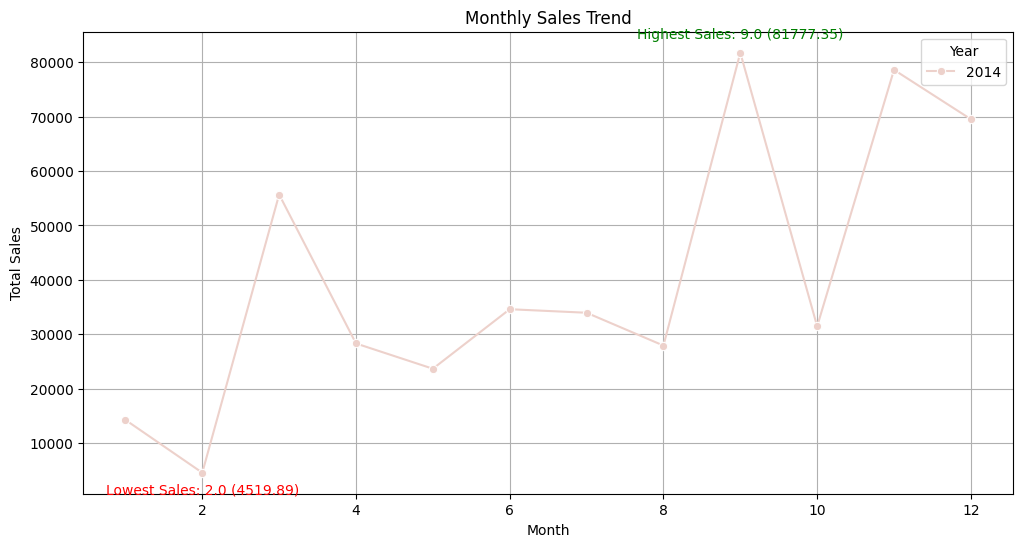

In [5]:
# Group by year and month to get monthly sales
monthly_sales = df.groupby(["order Year", "order Month"])["Sales"].sum().reset_index()

# Find the months with the highest and lowest sales
highest_sales = monthly_sales.loc[monthly_sales["Sales"].idxmax()]
lowest_sales = monthly_sales.loc[monthly_sales["Sales"].idxmin()]

# Plot the monthly sales trend
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_sales, x="order Month", y="Sales", hue="order Year", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.legend(title="Year")
plt.grid(True)

# Display the highest and lowest sales months
plt.annotate(f"Highest Sales: {highest_sales['order Month']} ({highest_sales['Sales']:.2f})",
             (highest_sales["order Month"], highest_sales["Sales"]),
             textcoords="offset points", xytext=(0,10), ha='center', color="green", fontsize=10)

plt.annotate(f"Lowest Sales: {lowest_sales['order Month']} ({lowest_sales['Sales']:.2f})",
             (lowest_sales["order Month"], lowest_sales["Sales"]),
             textcoords="offset points", xytext=(0,-15), ha='center', color="red", fontsize=10)

plt.show()


### SEPTEMBER ANALYSIS AND FEBRUARY ANALYSIS

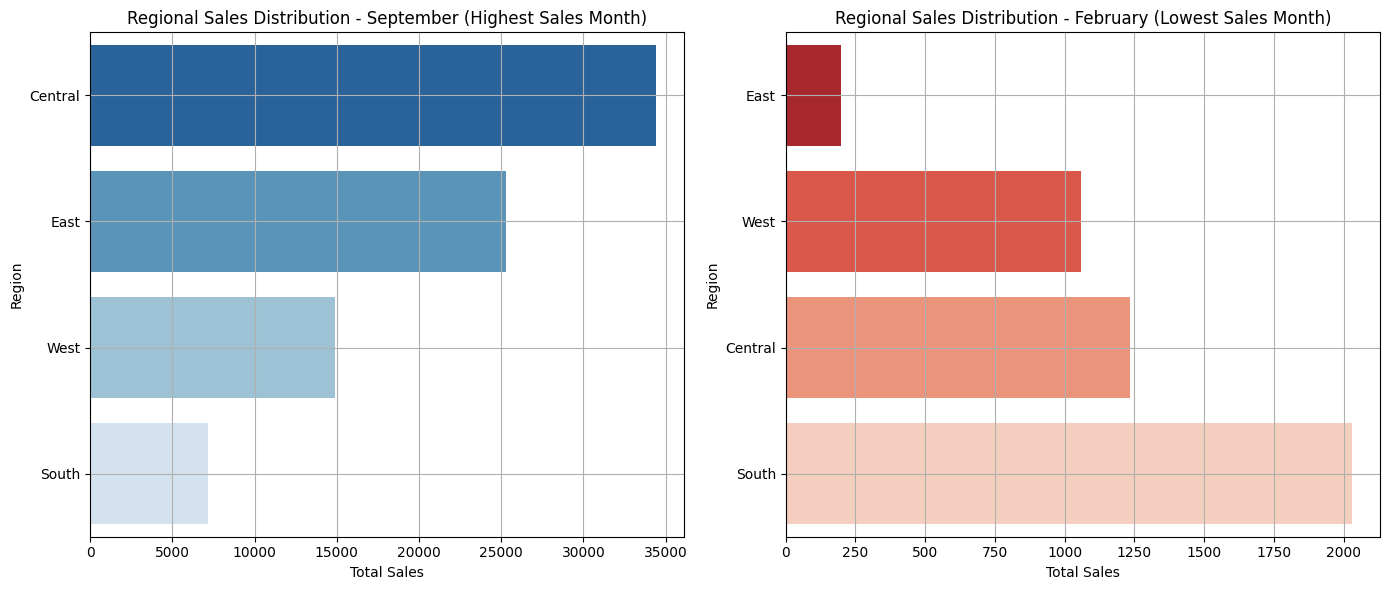

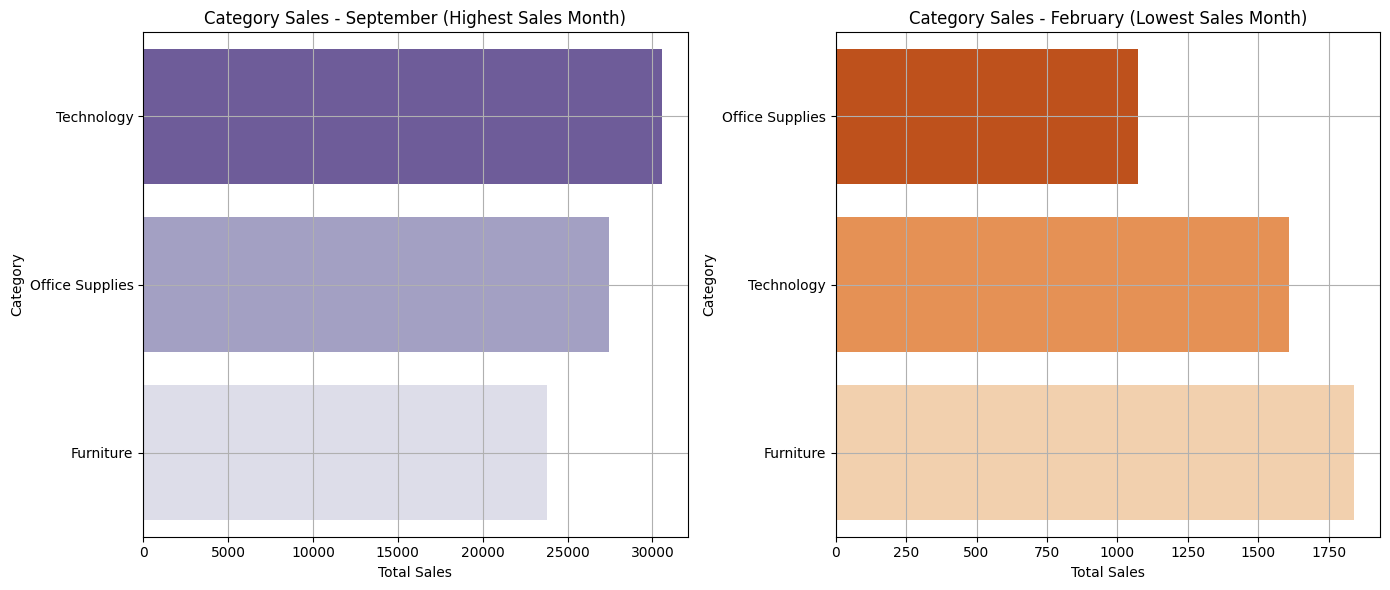

In [6]:
# SEPTEMBER ANALYSIS
# Filter September sales data
september_sales = df[df["order Month"] == 9]

# Group by region for September
september_region_sales = september_sales.groupby("Region")["Sales"].sum().reset_index().sort_values("Sales", ascending=False)

# Group by category for September
september_category_sales = september_sales.groupby("Category")["Sales"].sum().reset_index().sort_values("Sales", ascending=False)


# FEBRUARY ANALYSIS
# Filter February sales data
february_sales = df[df["order Month"] == 2]

# Group by category for February (lowest sales category)
february_category_sales = february_sales.groupby("Category")["Sales"].sum().reset_index().sort_values("Sales", ascending=True)

# Group by region for February (lowest sales region)
february_region_sales = february_sales.groupby("Region")["Sales"].sum().reset_index().sort_values("Sales", ascending=True)


# PLOT REGIONAL SALES FOR SEPTEMBER & FEBRUARY
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.barplot(data=september_region_sales, x="Sales", y="Region", palette="Blues_r")
plt.title("Regional Sales Distribution - September (Highest Sales Month)")
plt.xlabel("Total Sales")
plt.ylabel("Region")
plt.grid(True)

plt.subplot(1, 2, 2)
sns.barplot(data=february_region_sales, x="Sales", y="Region", palette="Reds_r")
plt.title("Regional Sales Distribution - February (Lowest Sales Month)")
plt.xlabel("Total Sales")
plt.ylabel("Region")
plt.grid(True)

plt.tight_layout()
plt.show()


# PLOT CATEGORY SALES FOR SEPTEMBER & FEBRUARY
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.barplot(data=september_category_sales, x="Sales", y="Category", palette="Purples_r")
plt.title("Category Sales - September (Highest Sales Month)")
plt.xlabel("Total Sales")
plt.ylabel("Category")
plt.grid(True)

plt.subplot(1, 2, 2)
sns.barplot(data=february_category_sales, x="Sales", y="Category", palette="Oranges_r")
plt.title("Category Sales - February (Lowest Sales Month)")
plt.xlabel("Total Sales")
plt.ylabel("Category")
plt.grid(True)

plt.tight_layout()
plt.show()


### FILTER DATA FOR SEPTEMBER

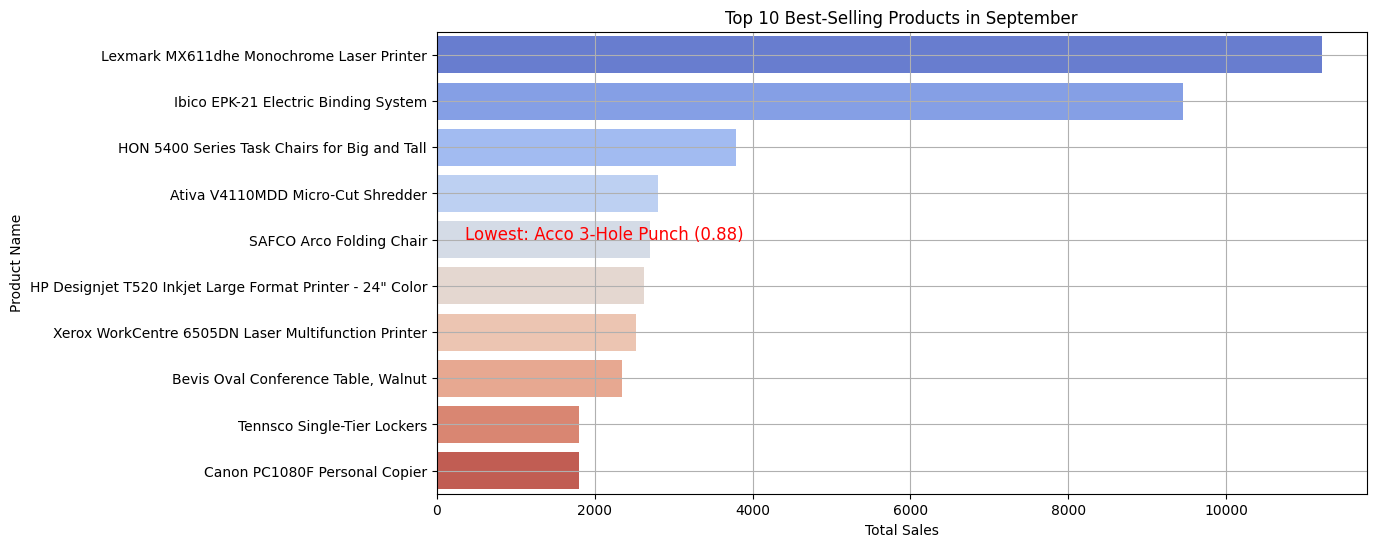

In [7]:
# Filter data for September
september_sales = df[df["order Month"] == 9]

# Group by product name and sum the sales
product_sales_september = september_sales.groupby("Product Name")["Sales"].sum().reset_index()

# Sort to get highest and lowest selling products
top_product = product_sales_september.nlargest(1, "Sales")
lowest_product = product_sales_september.nsmallest(1, "Sales")

# Plot sales distribution of products in September
plt.figure(figsize=(12, 6))
sns.barplot(data=product_sales_september.sort_values("Sales", ascending=False).head(10),
            x="Sales", y="Product Name", palette="coolwarm")

plt.title("Top 10 Best-Selling Products in September")
plt.xlabel("Total Sales")
plt.ylabel("Product Name")
plt.grid(True)

# Annotate highest and lowest selling products
plt.annotate(f"Highest: {top_product['Product Name'].values[0]} ({top_product['Sales'].values[0]:,.2f})",
             xy=(top_product['Sales'].values[0], top_product.index.values[0]),
             xytext=(20, 0), textcoords="offset points", color="green", fontsize=12)

plt.annotate(f"Lowest: {lowest_product['Product Name'].values[0]} ({lowest_product['Sales'].values[0]:,.2f})",
             xy=(lowest_product['Sales'].values[0], lowest_product.index.values[0]),
             xytext=(20, 0), textcoords="offset points", color="red", fontsize=12)

plt.show()


### FILTER DATA FOR FEBRUARY

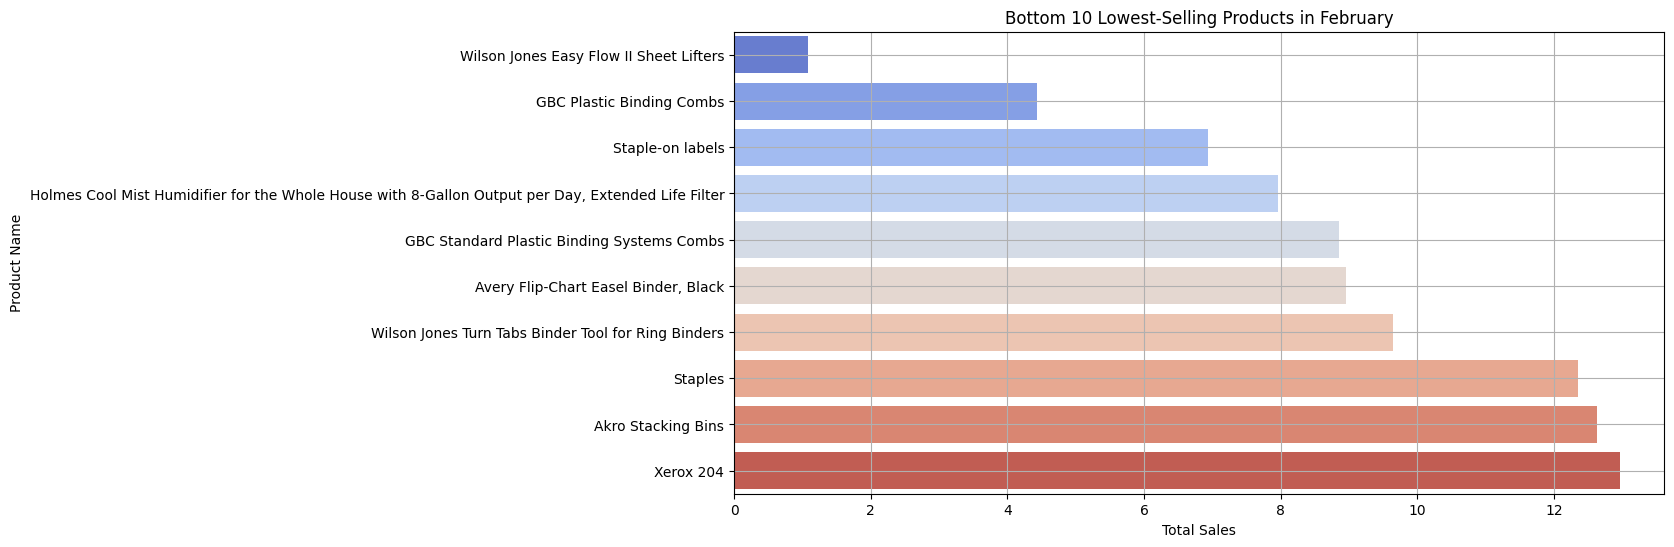

In [8]:
# Filter data for February
february_sales = df[df["order Month"] == 2]

# Group by product name and sum the sales
product_sales_february = february_sales.groupby("Product Name")["Sales"].sum().reset_index()

# Identify the lowest-selling product
lowest_product_february = product_sales_february.nsmallest(1, "Sales")

# Plot sales distribution of lowest-selling products in February
plt.figure(figsize=(12, 6))
sns.barplot(data=product_sales_february.sort_values("Sales", ascending=True).head(10),
            x="Sales", y="Product Name", palette="coolwarm")

plt.title("Bottom 10 Lowest-Selling Products in February")
plt.xlabel("Total Sales")
plt.ylabel("Product Name")
plt.grid(True)

# Annotate lowest-selling product
plt.annotate(f"Lowest: {lowest_product_february['Product Name'].values[0]} ({lowest_product_february['Sales'].values[0]:,.2f})",
             xy=(lowest_product_february['Sales'].values[0], lowest_product_february.index.values[0]),
             xytext=(20, 0), textcoords="offset points", color="red", fontsize=12)

plt.show()


### FILTER SEPTEMBER 2014 SALES DATA

In [9]:
# Filter September 2014 sales data
september_sales = df[(df["order Month"] == 9) & (df["order Year"] == 2014)]
top_segment_sept = september_sales.groupby("Segment")["Sales"].sum().idxmax()

# Filter February 2014 sales data
february_sales = df[(df["order Month"] == 2) & (df["order Year"] == 2014)]
bottom_segment_feb = february_sales.groupby("Segment")["Sales"].sum().idxmin()

print(f"📈 The highest spending customer segment in September 2014: {top_segment_sept}")
print(f"📉 The lowest spending customer segment in February 2014: {bottom_segment_feb}")


📈 The highest spending customer segment in September 2014: Consumer
📉 The lowest spending customer segment in February 2014: Home Office


### THE MOST SHIPPING MODE IN SEPTEMBER 2014

In [10]:
# Find most used shipping mode in September 2014
top_shipping_sept = september_sales["Ship Mode"].value_counts().idxmax()

# Find least used shipping mode in February 2014
bottom_shipping_feb = february_sales["Ship Mode"].value_counts().idxmin()

print(f"🚀 The most used shipping mode in September 2014: {top_shipping_sept}")
print(f"🐢 The least used shipping mode in February 2014: {bottom_shipping_feb}")


🚀 The most used shipping mode in September 2014: Standard Class
🐢 The least used shipping mode in February 2014: Same Day


### THE TOTAL PROFIT FOR SEPTEMBER 2014

In [11]:
# Calculate total profit for September 2014
total_profit_sept = september_sales["Profit"].sum()

# Calculate total profit for February 2014
total_profit_feb = february_sales["Profit"].sum()

print(f"💰 Total profit in September 2014: ${total_profit_sept:.2f}")
print(f"📉 Total profit in February 2014: ${total_profit_feb:.2f}")


💰 Total profit in September 2014: $8328.10
📉 Total profit in February 2014: $862.31


### THE NUMBER OF ORDERS IN SEPTEMBER AND FEBRUARY

In [12]:
# Calculate the number of orders in September and February
num_orders_sept = september_sales["Order ID"].nunique()
num_orders_feb = february_sales["Order ID"].nunique()

# Calculate average profit per order
avg_profit_per_order_sept = total_profit_sept / num_orders_sept
avg_profit_per_order_feb = total_profit_feb / num_orders_feb

print(f"💰 Average profit per order in September 2014: ${avg_profit_per_order_sept:.2f}")
print(f"📉 Average profit per order in February 2014: ${avg_profit_per_order_feb:.2f}")


💰 Average profit per order in September 2014: $64.06
📉 Average profit per order in February 2014: $30.80


### THE AVERAGE DISCOUNT PER ORDER IN SEPTEMBER AND FEBRUARY 2014

In [13]:
# Calculate the average discount per order in September 2014
avg_discount_sept = september_sales["Discount"].mean()

# Calculate the average discount per order in February 2014
avg_discount_feb = february_sales["Discount"].mean()

print(f"🔽 Average discount per order in September 2014: {avg_discount_sept:.2%}")
print(f"🔼 Average discount per order in February 2014: {avg_discount_feb:.2%}")


🔽 Average discount per order in September 2014: 16.00%
🔼 Average discount per order in February 2014: 17.61%


### THE AVERAGE QUANTITY PER ORDER IN SEPTEMBER AND FEBRUARY 2014

In [14]:
# Calculate average quantity per order in September 2014
avg_quantity_sept = september_sales["Quantity"].mean()

# Calculate average quantity per order in February 2014
avg_quantity_feb = february_sales["Quantity"].mean()

print(f"📦 Average quantity per order in September 2014: {avg_quantity_sept:.2f}")
print(f"📦 Average quantity per order in February 2014: {avg_quantity_feb:.2f}")


📦 Average quantity per order in September 2014: 3.73
📦 Average quantity per order in February 2014: 3.46


### THE TOTAL NUMBER OF ORDERS IN SEPTEMBER AND FEBRUARY 2014

In [15]:
# Total number of orders in September 2014
total_orders_sept = september_sales["Order ID"].nunique()

# Total number of orders in February 2014
total_orders_feb = february_sales["Order ID"].nunique()

print(f"🛒 Total orders in September 2014: {total_orders_sept}")
print(f"📉 Total orders in February 2014: {total_orders_feb}")


🛒 Total orders in September 2014: 130
📉 Total orders in February 2014: 28


## Sales Analysis: September vs February  

### 📊 Key Findings  

#### 🏆 September 2014 (Highest Sales)
- **Top-Selling Region:** Central  
- **Best-Selling Product:** Lexmark MX611dhe Monochrome Laser Printer  
- **Top-Selling Category:** Technology  
- **Total Profit:** $8,328.10  

- **Average Profit per Order:**  $64.06  
- **Total Orders:** 130  

#### 📉 February 2014 (Lowest Sales)
- **Lowest-Selling Region:** East  
- **Lowest-Selling Product:** Wilson Jones Easy Flow II Sheet  
- **Lowest-Selling Category:** Office Supplies  
- **Total Profit:** $862.31  

- **Average Profit per Order:** $30.80  
- **Total Orders:** 28  

### 🔍 Insights  
- **Furniture performed best in February**, while Office Supplies struggled the most.  
- **Technology had a major drop from September to February**, indicating possible **seasonality effects**.  
- The **Central region drove the highest sales in September**, despite having the lowest total profit overall, which suggests that while demand is strong, **high costs or heavy discounts may be reducing profitability**.  
- The **East region struggled the most in February**, indicating **regional variations in seasonal demand**.  

### 🚀 Recommendations  
- **Boost Office Supplies and Technology sales in February** through **promotions, discounts, or bundled offers**.  
- **Capitalize on Furniture's steady demand in low sales months** by maintaining stock and offering financing options.  
- **Target the East region with better marketing strategies in February** to improve sales performance.  
- **Encourage the use of Same Day shipping** with discounts or incentives to drive more sales.  
- **Investigate Consumer segment behaviors in September** to understand why they spend more and replicate similar strategies in other months.  

By leveraging these insights, we can create a **data-driven strategy** to optimize **sales and profitability** across all months. 📈✨


### REGIONAL PROFITABILITY ANALYSIS

In [16]:
# Filter data for the Central region
central_sales = df[df["Region"] == "Central"]

# Calculate Profit Margin for Central Region
total_sales_central = central_sales["Sales"].sum()
total_profit_central = central_sales["Profit"].sum()
profit_margin_central = (total_profit_central / total_sales_central) * 100

print(f"Central Region Profit Margin: {profit_margin_central:.2f}%")

# Compare with other regions
region_profit_margin = df.groupby("Region").apply(lambda x: (x["Profit"].sum() / x["Sales"].sum()) * 100)
print(region_profit_margin)

# Check if discounts are higher in the Central region (if Discount column exists)
if "Discount" in df.columns:
    avg_discount_central = central_sales["Discount"].mean()
    avg_discount_other_regions = df[df["Region"] != "Central"]["Discount"].mean()

    print(f"Avg Discount in Central: {avg_discount_central:.2f}")
    print(f"Avg Discount in Other Regions: {avg_discount_other_regions:.2f}")

    if avg_discount_central > avg_discount_other_regions:
        print("Higher discounts may be reducing profitability in the Central region.")


Central Region Profit Margin: 0.52%
Region
Central     0.519610
East       13.257343
South      11.439187
West       13.568623
dtype: float64
Avg Discount in Central: 0.26
Avg Discount in Other Regions: 0.13
Higher discounts may be reducing profitability in the Central region.


# Regional Profitability Analysis  

Understanding profitability across regions helps identify areas for improvement. While the **Central region had comparable sales to the South across the full year**, it also had the **lowest profit margin (0.52%)**, significantly lower than other regions, where profitability exceeded **11%**. This raises concerns about **high operational costs or excessive discounting** reducing profitability.  

## Key Findings:  

### **Profitability Variations:**  
- **Central Region Profit Margin:** 0.52%  
- **East:** 13.26%, **South:** 11.44%, **West:** 13.57%  

### **Discounting Impact:**  
- **Avg Discount in Central:** 26% (vs. 13% in other regions)  
- **Higher discounts may be eroding profitability despite strong sales.**  

## Recommendations:  

- **Optimize Discounting Strategies:** Evaluate if the high discounting in the Central region is driving sales or merely reducing profitability.  
- **Prioritize High-Margin Products:** Focus promotions on products with better profit margins instead of broad discounting.  
- **Analyze Consumer Demand Elasticity:** Determine the optimal pricing strategy to balance demand and profitability.  


## PAGE 1 — Discount Intelligence + Sales Impact

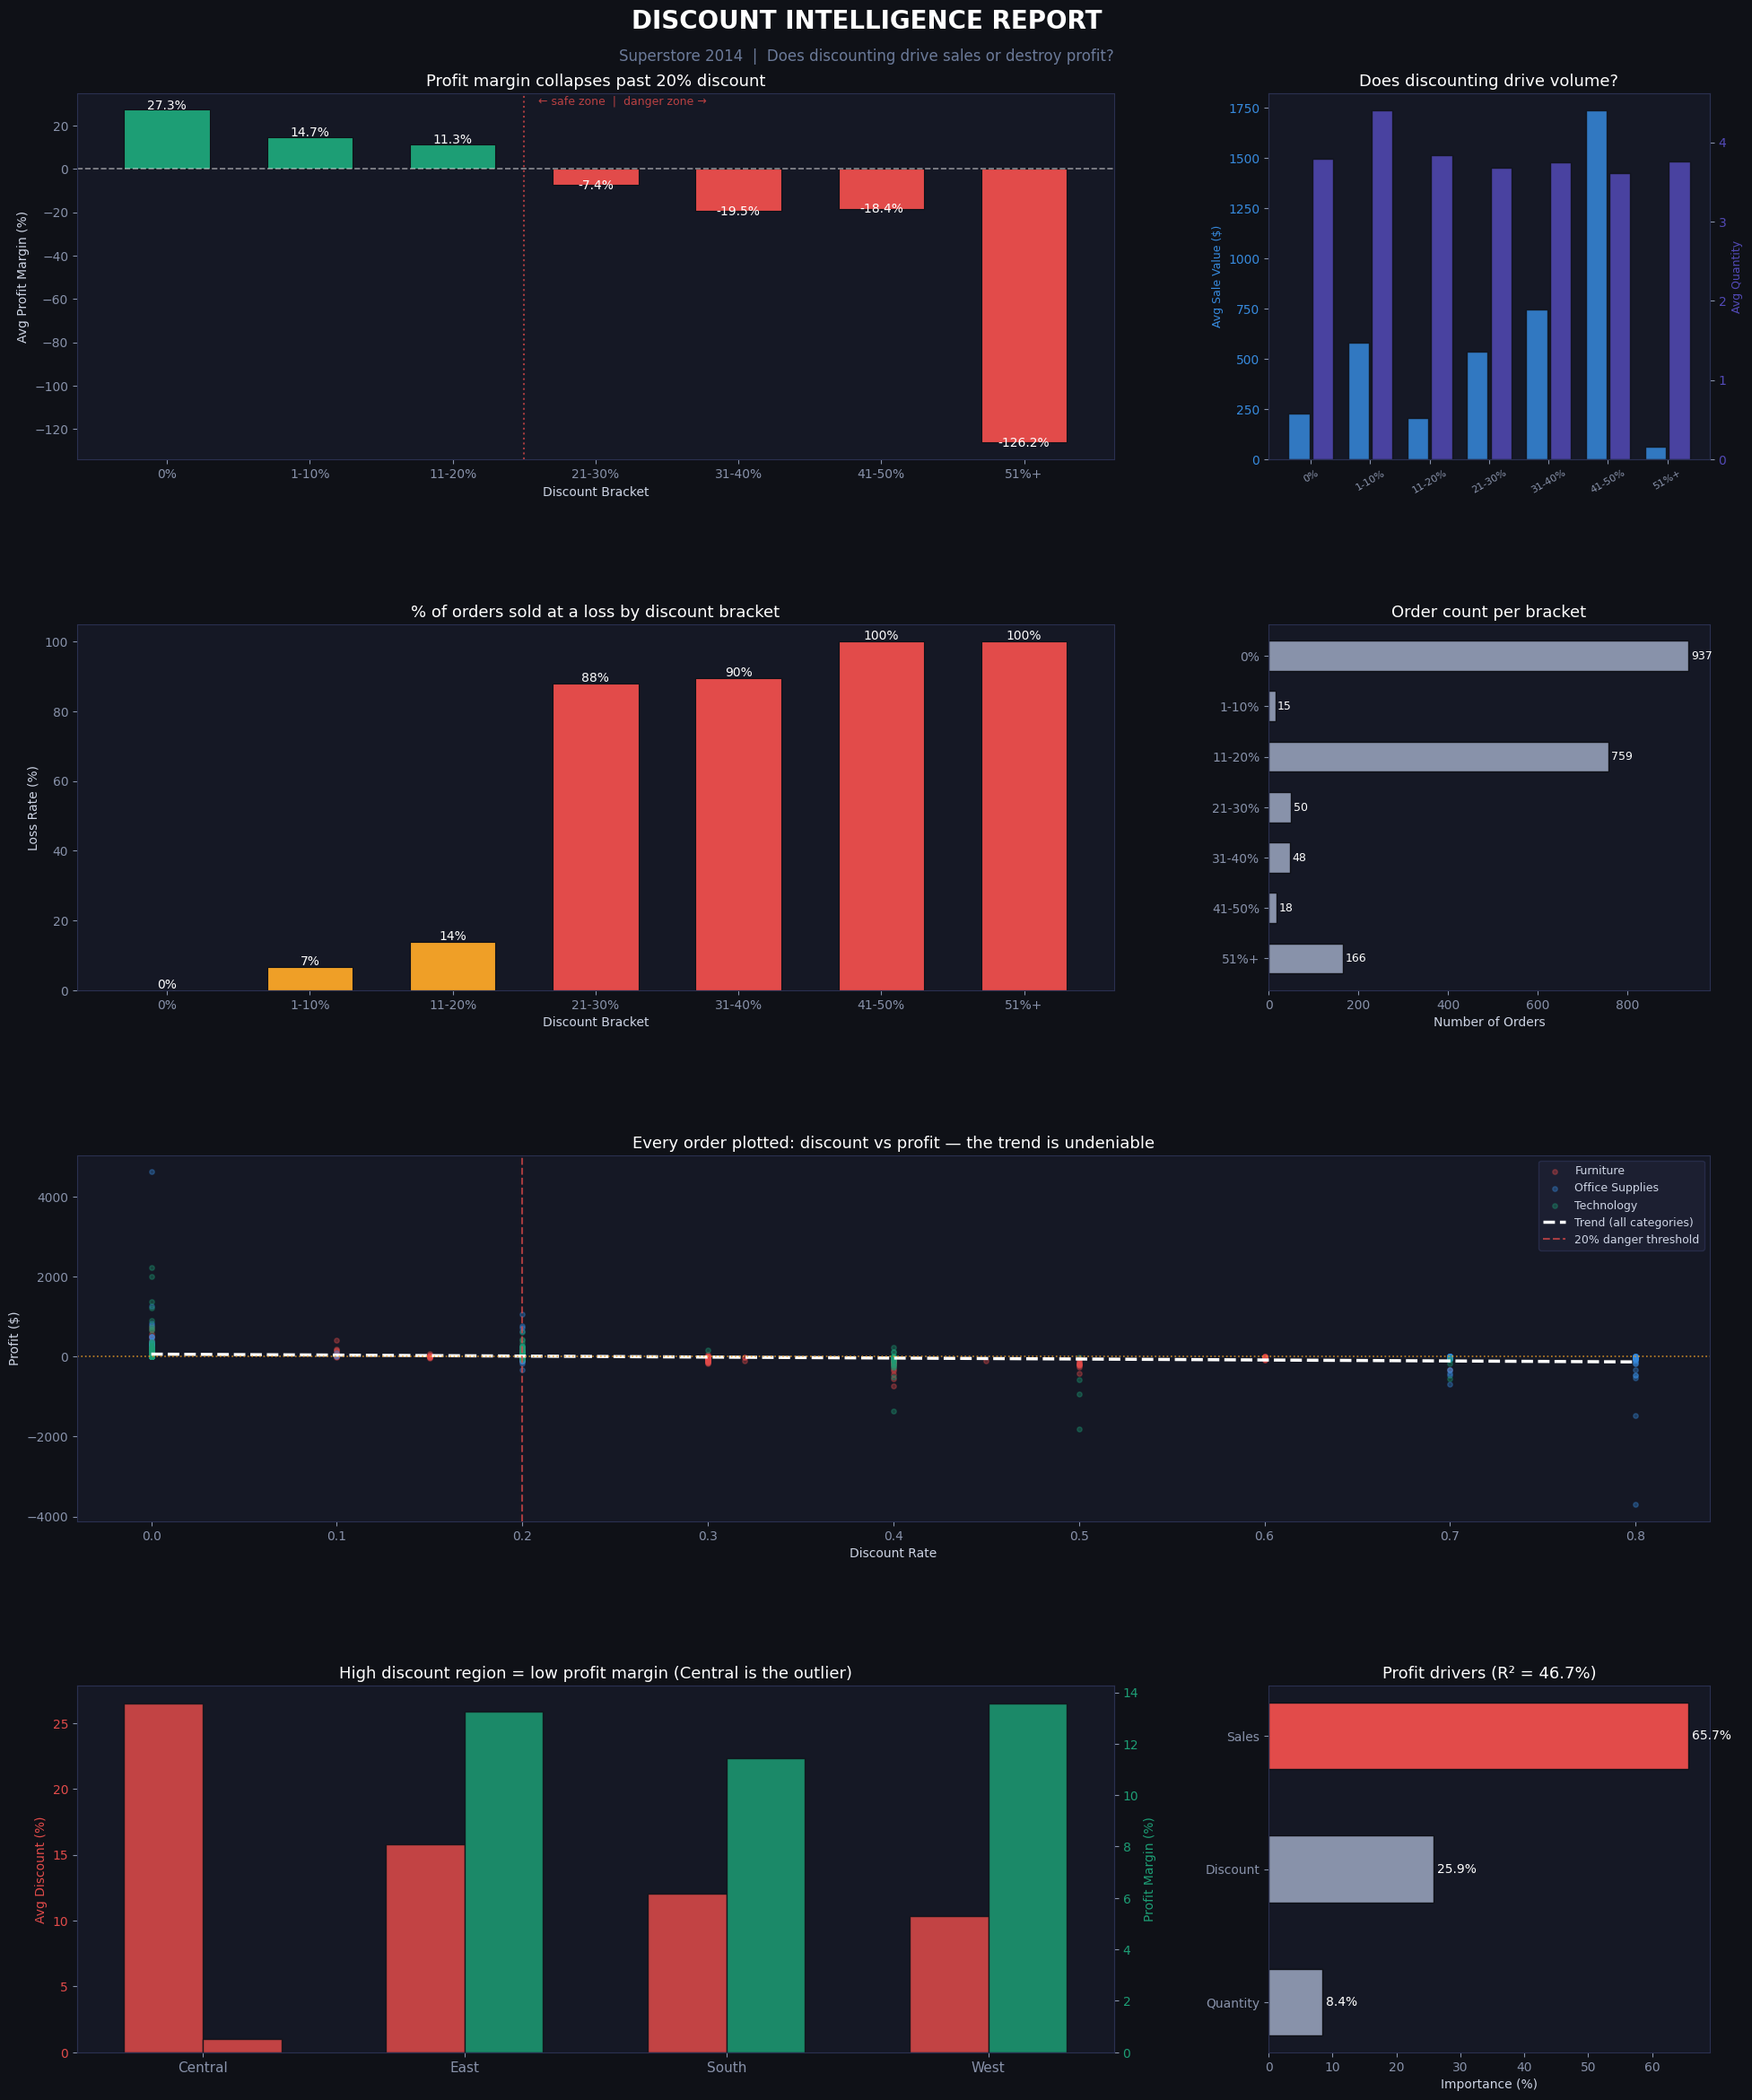

Page 1 saved ✅


In [17]:
# ═══════════════════════════════════════════════════════════════
#  PAGE 1: DISCOUNT INTELLIGENCE — Does It Help or Hurt?
# ═══════════════════════════════════════════════════════════════

plt.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor': '#151825',
    'axes.edgecolor': '#2a3050',   'axes.labelcolor': '#cdd4e4',
    'xtick.color': '#8892aa',      'ytick.color': '#8892aa',
    'text.color': '#cdd4e4',       'grid.color': '#1e2235',
    'grid.linestyle': '--',        'grid.alpha': 0.6,
    'axes.titlecolor': '#ffffff',  'axes.titlesize': 13,
    'axes.titleweight': '500'
})

fig = plt.figure(figsize=(20, 24))
fig.patch.set_facecolor('#0f1117')

# ── Header ──────────────────────────────────────────────────────
fig.text(0.5, 0.98, 'DISCOUNT INTELLIGENCE REPORT', ha='center',
         fontsize=20, fontweight='bold', color='white')
fig.text(0.5, 0.965, 'Superstore 2014  |  Does discounting drive sales or destroy profit?',
         ha='center', fontsize=12, color='#6b7a99')

gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.45, wspace=0.35,
                       top=0.95, bottom=0.04, left=0.06, right=0.97)

bracket_stats = df.groupby('Discount Bracket', observed=True).agg(
    Avg_Profit_Margin = ('Profit',   lambda x: (x.sum() / df.loc[x.index,'Sales'].sum()) * 100),
    Avg_Sales         = ('Sales',    'mean'),
    Avg_Quantity      = ('Quantity', 'mean'),
    Order_Count       = ('Profit',   'count'),
    Loss_Count        = ('Is Loss',  'sum')
).reset_index()
bracket_stats['Loss_Rate'] = bracket_stats['Loss_Count'] / bracket_stats['Order_Count'] * 100

# ── Chart 1: Profit Margin by Bracket ───────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
colors = ['#1d9e75' if v >= 5 else '#ef9f27' if v >= 0 else '#e24b4a'
          for v in bracket_stats['Avg_Profit_Margin']]
bars = ax1.bar(bracket_stats['Discount Bracket'], bracket_stats['Avg_Profit_Margin'],
               color=colors, edgecolor='#0f1117', linewidth=0.8, width=0.6)
for bar, val in zip(bars, bracket_stats['Avg_Profit_Margin']):
    ypos = bar.get_height() + 0.4 if val >= 0 else bar.get_height() - 1.8
    ax1.text(bar.get_x() + bar.get_width()/2, ypos,
             f'{val:.1f}%', ha='center', fontsize=10, fontweight='500', color='white')
ax1.axhline(0, color='white', linewidth=1.2, linestyle='--', alpha=0.5)
ax1.axvline(2.5, color='#e24b4a', linewidth=1.5, linestyle=':', alpha=0.7)
ax1.text(2.6, ax1.get_ylim()[1] * 0.85, '← safe zone  |  danger zone →',
         fontsize=9, color='#e24b4a', alpha=0.8)
ax1.set_title('Profit margin collapses past 20% discount')
ax1.set_xlabel('Discount Bracket')
ax1.set_ylabel('Avg Profit Margin (%)')
ax1.set_facecolor('#151825')

# ── Chart 2: Does Discount Drive More Sales? ─────────────────────
ax2 = fig.add_subplot(gs[0, 2])
ax2_twin = ax2.twinx()
x = np.arange(len(bracket_stats))
bars_s = ax2.bar(x - 0.2, bracket_stats['Avg_Sales'], 0.35,
                 color='#378add', alpha=0.85, edgecolor='#0f1117', label='Avg Sale Value ($)')
bars_q = ax2_twin.bar(x + 0.2, bracket_stats['Avg_Quantity'], 0.35,
                      color='#534ab7', alpha=0.85, edgecolor='#0f1117', label='Avg Quantity')
ax2.set_xticks(x)
ax2.set_xticklabels(bracket_stats['Discount Bracket'], rotation=30, fontsize=8)
ax2.set_ylabel('Avg Sale Value ($)', color='#378add', fontsize=9)
ax2_twin.set_ylabel('Avg Quantity', color='#534ab7', fontsize=9)
ax2.tick_params(axis='y', labelcolor='#378add')
ax2_twin.tick_params(axis='y', labelcolor='#534ab7')
ax2.set_title('Does discounting drive volume?')
ax2.set_facecolor('#151825')
ax2_twin.set_facecolor('#151825')

# ── Chart 3: Loss Rate by Bracket ───────────────────────────────
ax3 = fig.add_subplot(gs[1, :2])
loss_colors = ['#1d9e75' if v < 5 else '#ef9f27' if v < 20 else '#e24b4a'
               for v in bracket_stats['Loss_Rate']]
bars3 = ax3.bar(bracket_stats['Discount Bracket'], bracket_stats['Loss_Rate'],
                color=loss_colors, edgecolor='#0f1117', linewidth=0.8, width=0.6)
for bar, val in zip(bars3, bracket_stats['Loss_Rate']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.0f}%', ha='center', fontsize=10, fontweight='500', color='white')
ax3.set_title('% of orders sold at a loss by discount bracket')
ax3.set_xlabel('Discount Bracket')
ax3.set_ylabel('Loss Rate (%)')
ax3.set_facecolor('#151825')

# ── Chart 4: Order Count by Bracket ─────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
ax4.barh(bracket_stats['Discount Bracket'], bracket_stats['Order_Count'],
         color='#8892aa', edgecolor='#0f1117', height=0.6)
for i, val in enumerate(bracket_stats['Order_Count']):
    ax4.text(val + 5, i, str(val), va='center', fontsize=9, color='white')
ax4.set_title('Order count per bracket')
ax4.set_xlabel('Number of Orders')
ax4.set_facecolor('#151825')
ax4.invert_yaxis()

# ── Chart 5: Scatter — Discount vs Profit (all orders) ──────────
ax5 = fig.add_subplot(gs[2, :])
cat_colors = {'Furniture': '#e24b4a', 'Office Supplies': '#378add', 'Technology': '#1d9e75'}
for cat, col in cat_colors.items():
    sub = df[df['Category'] == cat]
    ax5.scatter(sub['Discount'], sub['Profit'], alpha=0.35, s=15,
                color=col, label=cat)
z = np.polyfit(df['Discount'], df['Profit'], 1)
p = np.poly1d(z)
x_line = np.linspace(0, df['Discount'].max(), 200)
ax5.plot(x_line, p(x_line), color='white', linewidth=2.5,
         linestyle='--', label='Trend (all categories)')
ax5.axhline(0, color='#ef9f27', linewidth=1.2, linestyle=':', alpha=0.8)
ax5.axvline(0.2, color='#e24b4a', linewidth=1.5, linestyle='--',
            alpha=0.7, label='20% danger threshold')
ax5.set_title('Every order plotted: discount vs profit — the trend is undeniable')
ax5.set_xlabel('Discount Rate')
ax5.set_ylabel('Profit ($)')
ax5.legend(facecolor='#1e2235', edgecolor='#2a3050', fontsize=9)
ax5.set_facecolor('#151825')

# ── Chart 6: Regional Deep Dive ──────────────────────────────────
ax6 = fig.add_subplot(gs[3, :2])
region_stats = df.groupby('Region').agg(
    Avg_Discount     = ('Discount', 'mean'),
    Profit_Margin    = ('Profit',   lambda x: (x.sum() / df.loc[x.index,'Sales'].sum()) * 100),
    Total_Sales      = ('Sales',    'sum'),
    Avg_Sales_Per_Order = ('Sales', 'mean')
).reset_index().sort_values('Avg_Discount', ascending=False)

x_r = np.arange(len(region_stats))
w = 0.3
ax6b = ax6.twinx()
b1 = ax6.bar(x_r - w/2, region_stats['Avg_Discount'] * 100, w,
             color='#e24b4a', alpha=0.85, edgecolor='#0f1117', label='Avg Discount %')
b2 = ax6b.bar(x_r + w/2, region_stats['Profit_Margin'], w,
              color=['#1d9e75' if v > 5 else '#e24b4a' for v in region_stats['Profit_Margin']],
              alpha=0.85, edgecolor='#0f1117', label='Profit Margin %')
ax6.set_xticks(x_r)
ax6.set_xticklabels(region_stats['Region'], fontsize=11)
ax6.set_ylabel('Avg Discount (%)', color='#e24b4a')
ax6b.set_ylabel('Profit Margin (%)', color='#1d9e75')
ax6.tick_params(axis='y', labelcolor='#e24b4a')
ax6b.tick_params(axis='y', labelcolor='#1d9e75')
ax6.set_title('High discount region = low profit margin (Central is the outlier)')
ax6.set_facecolor('#151825')
ax6b.set_facecolor('#151825')

# ── Chart 7: ML Feature Importance ──────────────────────────────
ax7 = fig.add_subplot(gs[3, 2])
features = ['Discount', 'Quantity', 'Sales']
X = df[features].dropna()
y = df.loc[X.index, 'Profit']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
r2 = r2_score(y_test, rf.predict(X_test))
imp = pd.Series(rf.feature_importances_, index=features).sort_values()
fi_colors = ['#8892aa', '#8892aa', '#e24b4a']
ax7.barh(imp.index, imp.values * 100, color=fi_colors, edgecolor='#0f1117', height=0.5)
for i, val in enumerate(imp.values * 100):
    ax7.text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=10, color='white')
ax7.set_title(f'Profit drivers (R² = {r2:.1%})')
ax7.set_xlabel('Importance (%)')
ax7.set_facecolor('#151825')

plt.savefig('Page1_Discount_Intelligence.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print("Page 1 saved ✅")

## Page 1 Findings Print

In [24]:
# ── Key Findings ────────────────────────────────────────────────
central   = df[df['Region'] == 'Central']
c_disc    = central['Discount'].mean() * 100
c_margin  = central['Profit'].sum() / central['Sales'].sum() * 100
loss_n    = df['Is Loss'].sum()
loss_pct  = loss_n / len(df) * 100
leaked    = df[df['Discount'] > 0.2]['Profit'].sum()

# Does discount drive volume?
no_disc   = df[df['Discount'] == 0]['Quantity'].mean()
high_disc = df[df['Discount'] > 0.2]['Quantity'].mean()
vol_lift  = ((high_disc - no_disc) / no_disc) * 100

print("=" * 60)
print("  PAGE 1 — DISCOUNT INTELLIGENCE: KEY FINDINGS")
print("=" * 60)
print(f"\n📌 Central avg discount:          {c_disc:.1f}%")
print(f"📌 Central profit margin:         {c_margin:.2f}%")
print(f"📌 Loss-making orders:            {loss_n} ({loss_pct:.1f}% of all orders)")
print(f"📌 Profit destroyed (>20% disc):  ${leaked:,.0f}")
print(f"📌 ML model accuracy (R²):        {r2:.1%}")
print(f"\n🔍 DOES DISCOUNTING DRIVE MORE VOLUME?")
print(f"   Avg quantity, no discount:     {no_disc:.2f} units/order")
print(f"   Avg quantity, >20% discount:   {high_disc:.2f} units/order")
print(f"   Volume lift from discounting:  {vol_lift:+.1f}%")
if abs(vol_lift) < 15:
    print(f"\n   ⚠️  VERDICT: Discounting gives only {vol_lift:.1f}% more volume")
    print(f"       but destroys margin. It is NOT justified by volume gains.")
else:
    print(f"\n   ✅ VERDICT: Discounting does drive meaningful volume lift.")

print(f"\n{'='*60}")
print("\n🔑 RECOMMENDATIONS")
print("-" * 60)
print("1. Cap all discounts at 20% — losses spike sharply beyond this.")
print("2. Audit Central region: 26.5% avg discount with 0.52% margin")
print("   means they are essentially selling at cost.")
print("3. Discounting is NOT earning more volume to justify the margin loss.")
print("4. Introduce a discount approval gate above 15% for managers.")
print("5. Track discount ROI per rep: profit per dollar of discount given.")

  PAGE 1 — DISCOUNT INTELLIGENCE: KEY FINDINGS

📌 Central avg discount:          26.5%
📌 Central profit margin:         0.52%
📌 Loss-making orders:            377 (18.9% of all orders)
📌 Profit destroyed (>20% disc):  $-28,044
📌 ML model accuracy (R²):        46.7%

🔍 DOES DISCOUNTING DRIVE MORE VOLUME?
   Avg quantity, no discount:     3.79 units/order
   Avg quantity, >20% discount:   3.73 units/order
   Volume lift from discounting:  -1.5%

   ⚠️  VERDICT: Discounting gives only -1.5% more volume
       but destroys margin. It is NOT justified by volume gains.


🔑 RECOMMENDATIONS
------------------------------------------------------------
1. Cap all discounts at 20% — losses spike sharply beyond this.
2. Audit Central region: 26.5% avg discount with 0.52% margin
   means they are essentially selling at cost.
3. Discounting is NOT earning more volume to justify the margin loss.
4. Introduce a discount approval gate above 15% for managers.
5. Track discount ROI per rep: profit per do

## PAGE 2: DOES DISCOUNTING EVEN WORK?

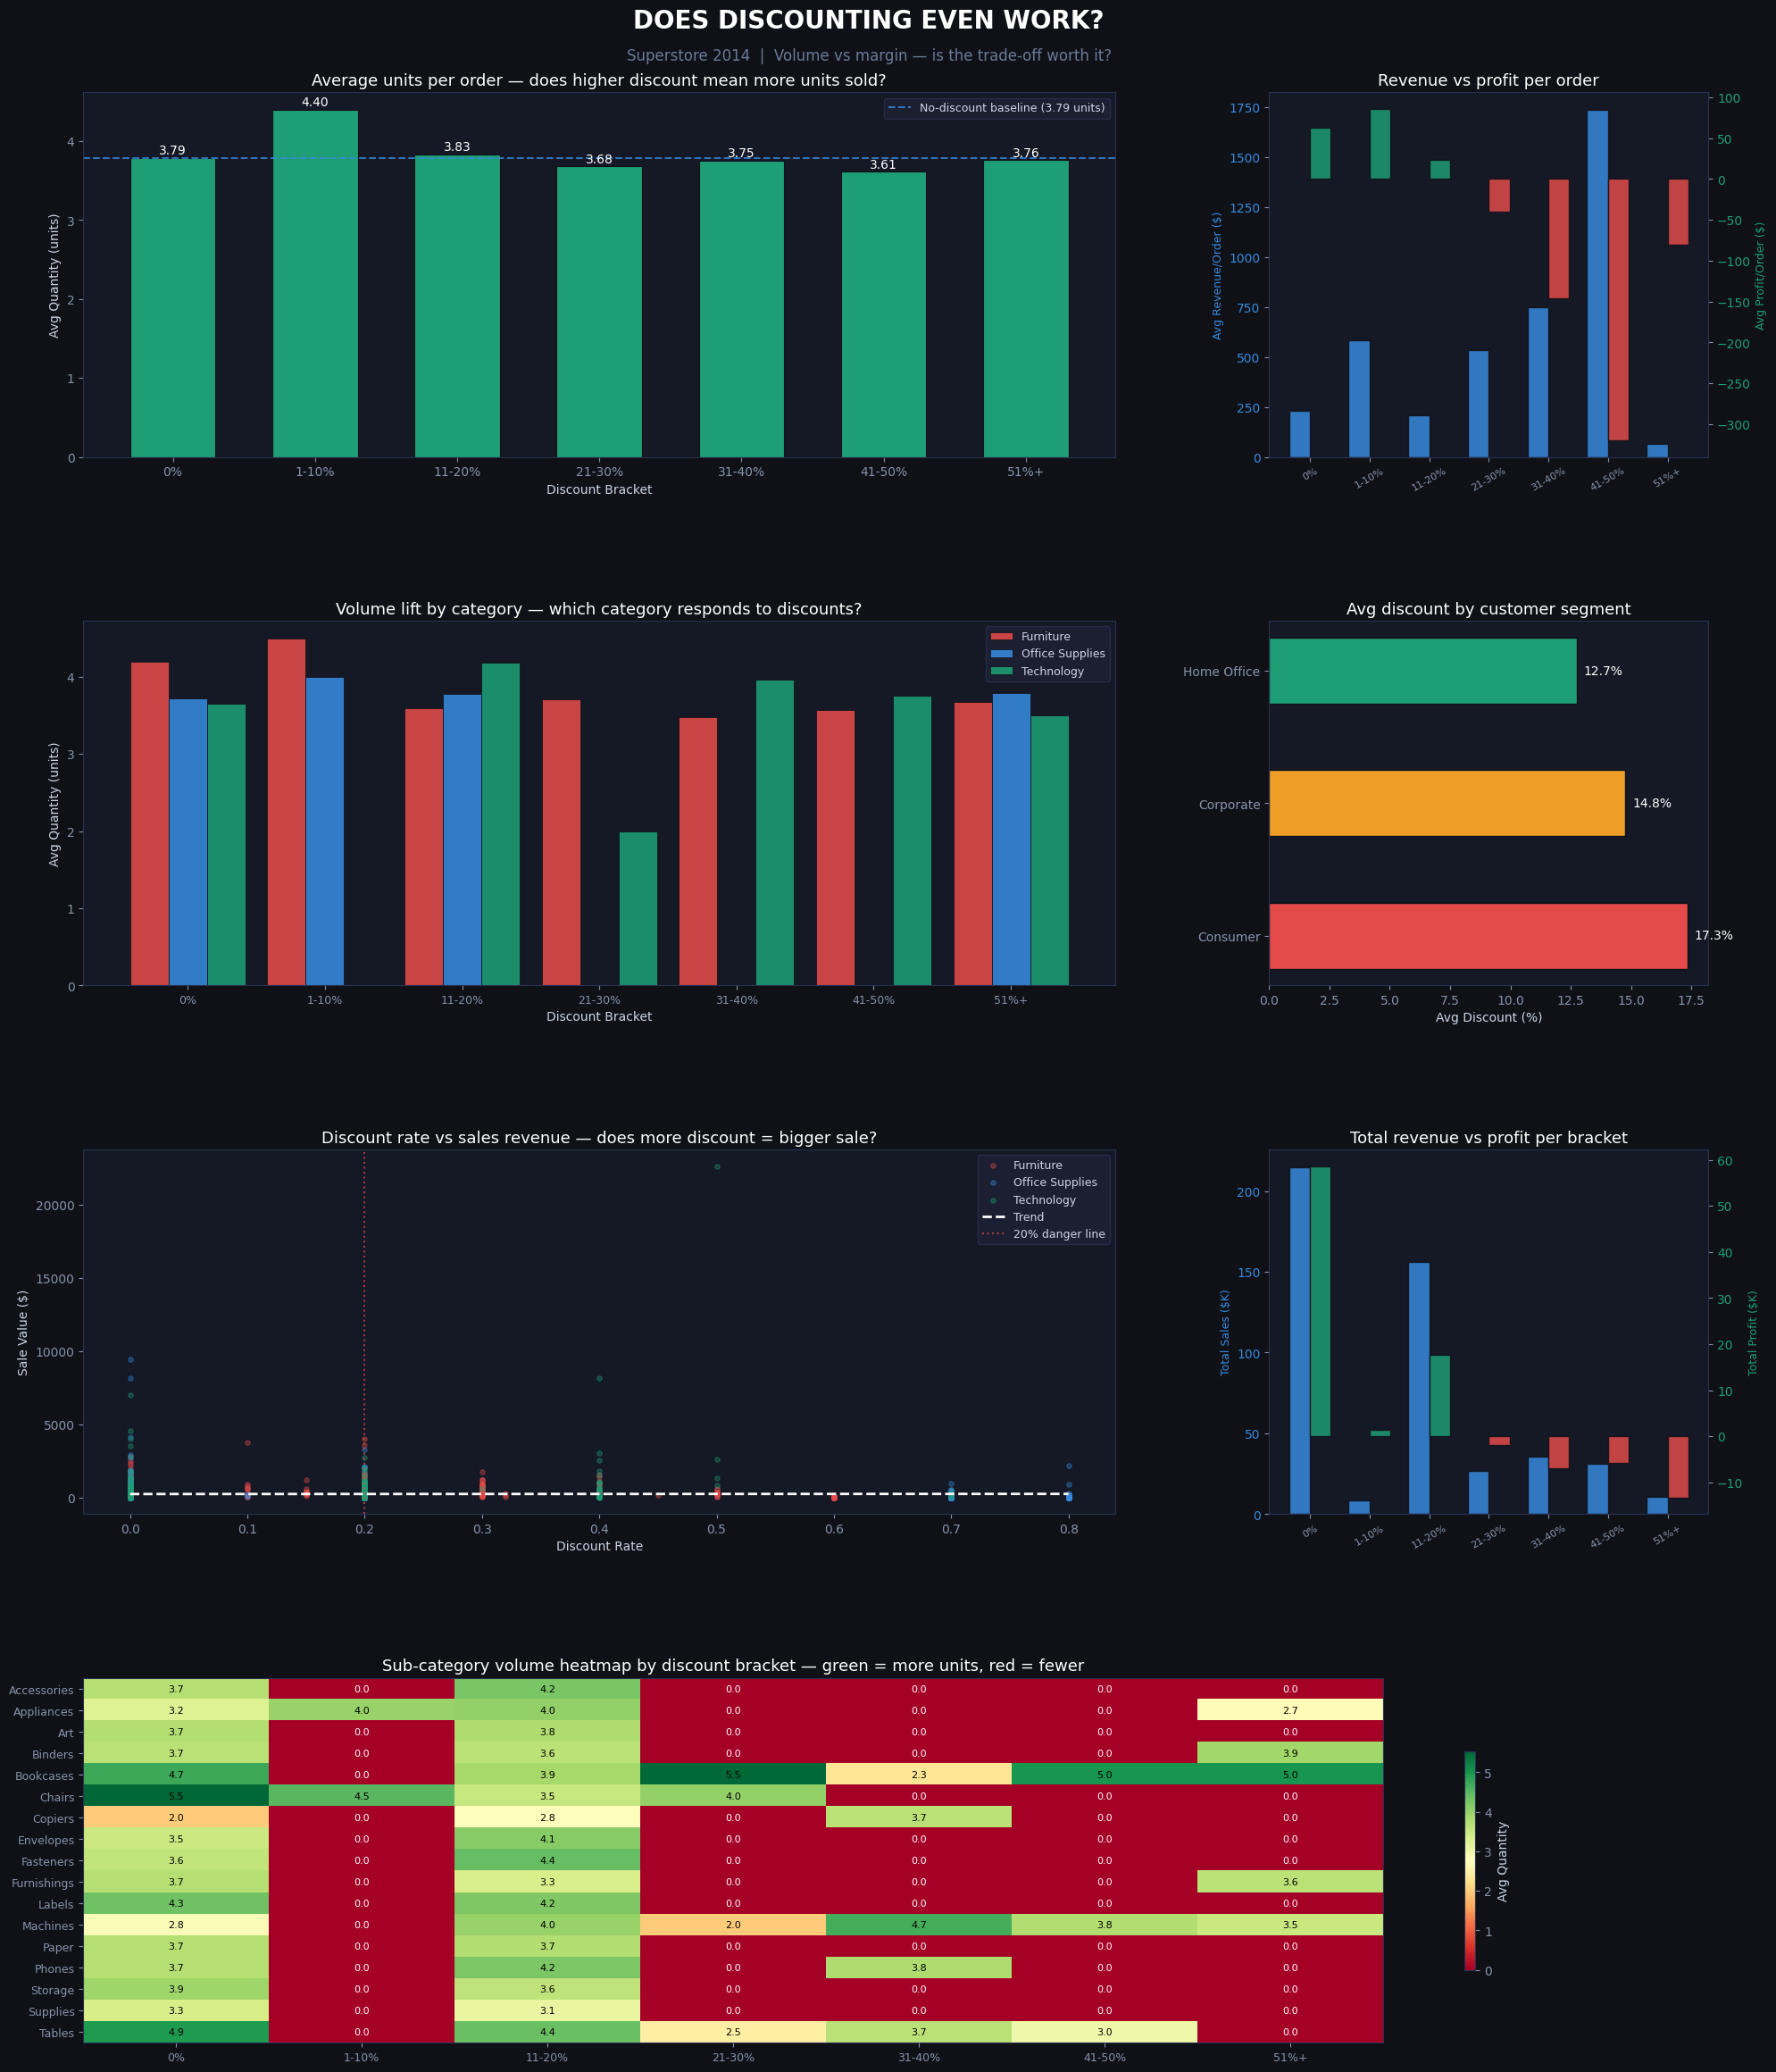

Page 2 saved ✅


In [22]:
# ═══════════════════════════════════════════════════════════════
#  PAGE 2: DOES DISCOUNTING EVEN WORK?
#  Volume analysis — does giving discounts actually drive sales?
# ═══════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(20, 24))
fig.patch.set_facecolor('#0f1117')

fig.text(0.5, 0.98, 'DOES DISCOUNTING EVEN WORK?', ha='center',
         fontsize=20, fontweight='bold', color='white')
fig.text(0.5, 0.965,
         'Superstore 2014  |  Volume vs margin — is the trade-off worth it?',
         ha='center', fontsize=12, color='#6b7a99')

gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.45, wspace=0.35,
                       top=0.95, bottom=0.04, left=0.06, right=0.97)

# ── Shared bracket summary ───────────────────────────────────────
bracket = df.groupby('Discount Bracket', observed=True).agg(
    Avg_Quantity    = ('Quantity', 'mean'),
    Avg_Sales       = ('Sales',    'mean'),
    Total_Sales     = ('Sales',    'sum'),
    Total_Profit    = ('Profit',   'sum'),
    Order_Count     = ('Profit',   'count'),
    Loss_Rate       = ('Is Loss',  'mean')
).reset_index()
bracket['Loss_Rate_Pct'] = bracket['Loss_Rate'] * 100
bracket['Profit_Per_Order'] = bracket['Total_Profit'] / bracket['Order_Count']

# ── Chart 1: Avg Quantity per Discount Bracket ───────────────────
ax1 = fig.add_subplot(gs[0, :2])
colors1 = ['#1d9e75' if v >= 3.5 else '#ef9f27' if v >= 2.5 else '#e24b4a'
           for v in bracket['Avg_Quantity']]
bars1 = ax1.bar(bracket['Discount Bracket'], bracket['Avg_Quantity'],
                color=colors1, edgecolor='#0f1117', linewidth=0.8, width=0.6)
for bar, val in zip(bars1, bracket['Avg_Quantity']):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
             f'{val:.2f}', ha='center', fontsize=10, fontweight='500', color='white')
baseline = df[df['Discount'] == 0]['Quantity'].mean()
ax1.axhline(baseline, color='#378add', linewidth=1.5,
            linestyle='--', alpha=0.8, label=f'No-discount baseline ({baseline:.2f} units)')
ax1.set_title('Average units per order — does higher discount mean more units sold?')
ax1.set_xlabel('Discount Bracket')
ax1.set_ylabel('Avg Quantity (units)')
ax1.legend(facecolor='#1e2235', edgecolor='#2a3050', fontsize=9)
ax1.set_facecolor('#151825')

# ── Chart 2: Revenue vs Profit per Order ────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
x2 = np.arange(len(bracket))
w2 = 0.35
ax2b = ax2.twinx()
ax2.bar(x2 - w2 / 2, bracket['Avg_Sales'], w2,
        color='#378add', alpha=0.85, edgecolor='#0f1117', label='Avg Revenue/Order')
ax2b.bar(x2 + w2 / 2, bracket['Profit_Per_Order'], w2,
         color=['#1d9e75' if v >= 0 else '#e24b4a' for v in bracket['Profit_Per_Order']],
         alpha=0.85, edgecolor='#0f1117', label='Avg Profit/Order')
ax2.set_xticks(x2)
ax2.set_xticklabels(bracket['Discount Bracket'], rotation=30, fontsize=8)
ax2.set_ylabel('Avg Revenue/Order ($)', color='#378add', fontsize=9)
ax2b.set_ylabel('Avg Profit/Order ($)', color='#1d9e75', fontsize=9)
ax2.tick_params(axis='y', labelcolor='#378add')
ax2b.tick_params(axis='y', labelcolor='#1d9e75')
ax2.set_title('Revenue vs profit per order')
ax2.set_facecolor('#151825')
ax2b.set_facecolor('#151825')

# ── Chart 3: Volume Lift by Category ────────────────────────────
ax3 = fig.add_subplot(gs[1, :2])
cat_bracket = df.groupby(['Category', 'Discount Bracket'],
                         observed=True)['Quantity'].mean().reset_index()
cat_pivot = cat_bracket.pivot(index='Discount Bracket',
                               columns='Category', values='Quantity')
cat_colors_map = {
    'Furniture':       '#e24b4a',
    'Office Supplies': '#378add',
    'Technology':      '#1d9e75'
}
x3 = np.arange(len(cat_pivot))
w3 = 0.28
for i, cat in enumerate(cat_pivot.columns):
    offset = (i - 1) * w3
    ax3.bar(x3 + offset, cat_pivot[cat], w3,
            label=cat, color=cat_colors_map.get(cat, '#8892aa'),
            edgecolor='#0f1117', linewidth=0.6, alpha=0.88)
ax3.set_xticks(x3)
ax3.set_xticklabels(cat_pivot.index, fontsize=9)
ax3.set_title('Volume lift by category — which category responds to discounts?')
ax3.set_xlabel('Discount Bracket')
ax3.set_ylabel('Avg Quantity (units)')
ax3.legend(facecolor='#1e2235', edgecolor='#2a3050', fontsize=9)
ax3.set_facecolor('#151825')

# ── Chart 4: Segment — who gets discounted most? ─────────────────
ax4 = fig.add_subplot(gs[1, 2])
seg = df.groupby('Segment').agg(
    Avg_Discount  = ('Discount',  'mean'),
    Avg_Quantity  = ('Quantity',  'mean'),
    Profit_Margin = ('Profit',    lambda x: (x.sum() / df.loc[x.index, 'Sales'].sum()) * 100)
).reset_index().sort_values('Avg_Discount', ascending=False)

bars4 = ax4.barh(seg['Segment'], seg['Avg_Discount'] * 100,
                 color=['#e24b4a', '#ef9f27', '#1d9e75'],
                 edgecolor='#0f1117', height=0.5)
for bar, val in zip(bars4, seg['Avg_Discount'] * 100):
    ax4.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
             f'{val:.1f}%', va='center', fontsize=10, color='white')
ax4.set_title('Avg discount by customer segment')
ax4.set_xlabel('Avg Discount (%)')
ax4.set_facecolor('#151825')

# ── Chart 5: Discount vs Sales Revenue scatter ────────────────────
ax5 = fig.add_subplot(gs[2, :2])
for cat, col in cat_colors_map.items():
    sub = df[df['Category'] == cat]
    ax5.scatter(sub['Discount'], sub['Sales'],
                alpha=0.35, s=15, color=col, label=cat)
z5 = np.polyfit(df['Discount'], df['Sales'], 1)
p5 = np.poly1d(z5)
x_line = np.linspace(0, df['Discount'].max(), 200)
ax5.plot(x_line, p5(x_line), color='white', linewidth=2,
         linestyle='--', label='Trend')
ax5.axvline(0.2, color='#e24b4a', linewidth=1.5,
            linestyle=':', alpha=0.7, label='20% danger line')
ax5.set_title('Discount rate vs sales revenue — does more discount = bigger sale?')
ax5.set_xlabel('Discount Rate')
ax5.set_ylabel('Sale Value ($)')
ax5.legend(facecolor='#1e2235', edgecolor='#2a3050', fontsize=9)
ax5.set_facecolor('#151825')

# ── Chart 6: Total Sales vs Total Profit by Bracket ──────────────
ax6 = fig.add_subplot(gs[2, 2])
x6 = np.arange(len(bracket))
w6 = 0.35
ax6b = ax6.twinx()
ax6.bar(x6 - w6 / 2, bracket['Total_Sales'] / 1000, w6,
        color='#378add', alpha=0.85, edgecolor='#0f1117', label='Total Sales ($K)')
ax6b.bar(x6 + w6 / 2, bracket['Total_Profit'] / 1000, w6,
         color=['#1d9e75' if v >= 0 else '#e24b4a' for v in bracket['Total_Profit']],
         alpha=0.85, edgecolor='#0f1117', label='Total Profit ($K)')
ax6.set_xticks(x6)
ax6.set_xticklabels(bracket['Discount Bracket'], rotation=30, fontsize=8)
ax6.set_ylabel('Total Sales ($K)', color='#378add', fontsize=9)
ax6b.set_ylabel('Total Profit ($K)', color='#1d9e75', fontsize=9)
ax6.tick_params(axis='y', labelcolor='#378add')
ax6b.tick_params(axis='y', labelcolor='#1d9e75')
ax6.set_title('Total revenue vs profit per bracket')
ax6.set_facecolor('#151825')
ax6b.set_facecolor('#151825')

# ── Chart 7: Sub-Category Volume Lift Heatmap ────────────────────
ax7 = fig.add_subplot(gs[3, :])
subcat_bracket = df.groupby(['Sub-Category', 'Discount Bracket'],
                             observed=True)['Quantity'].mean().reset_index()
pivot7 = subcat_bracket.pivot(index='Sub-Category',
                               columns='Discount Bracket',
                               values='Quantity').fillna(0)
im = ax7.imshow(pivot7.values, aspect='auto', cmap='RdYlGn', interpolation='nearest')
ax7.set_xticks(range(len(pivot7.columns)))
ax7.set_xticklabels(pivot7.columns, fontsize=9)
ax7.set_yticks(range(len(pivot7.index)))
ax7.set_yticklabels(pivot7.index, fontsize=9)
for i in range(len(pivot7.index)):
    for j in range(len(pivot7.columns)):
        val = pivot7.values[i, j]
        ax7.text(j, i, f'{val:.1f}', ha='center', va='center',
                 fontsize=8, color='black' if 1 < val < 8 else 'white')
plt.colorbar(im, ax=ax7, shrink=0.6, label='Avg Quantity')
ax7.set_title('Sub-category volume heatmap by discount bracket — green = more units, red = fewer')
ax7.set_facecolor('#151825')

plt.savefig('Page2_Does_Discounting_Work.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("Page 2 saved ✅")

## Page 2 Findings Print

In [23]:
no_disc_qty  = df[df['Discount'] == 0]['Quantity'].mean()
hi_disc_qty  = df[df['Discount'] > 0.2]['Quantity'].mean()
vol_lift     = (hi_disc_qty - no_disc_qty) / no_disc_qty * 100

no_disc_sale = df[df['Discount'] == 0]['Sales'].mean()
hi_disc_sale = df[df['Discount'] > 0.2]['Sales'].mean()
rev_lift     = (hi_disc_sale - no_disc_sale) / no_disc_sale * 100

no_disc_prof = df[df['Discount'] == 0]['Profit'].mean()
hi_disc_prof = df[df['Discount'] > 0.2]['Profit'].mean()

print("=" * 60)
print("  PAGE 2 — DOES DISCOUNTING EVEN WORK? KEY FINDINGS")
print("=" * 60)
print(f"\n📦 Volume (units/order)")
print(f"   No discount:      {no_disc_qty:.2f} units")
print(f"   Above 20% disc:   {hi_disc_qty:.2f} units")
print(f"   Volume lift:      {vol_lift:+.1f}%")

print(f"\n💰 Revenue (per order)")
print(f"   No discount:      ${no_disc_sale:.2f}")
print(f"   Above 20% disc:   ${hi_disc_sale:.2f}")
print(f"   Revenue lift:     {rev_lift:+.1f}%")

print(f"\n📉 Profit (per order)")
print(f"   No discount:      ${no_disc_prof:.2f}")
print(f"   Above 20% disc:   ${hi_disc_prof:.2f}")

print(f"\n{'='*60}")
print("\n⚖️  VERDICT")
print("-" * 60)
if abs(vol_lift) < 20:
    print(f"Discounting above 20% delivers only {vol_lift:.1f}% more volume")
    print("but profit per order drops sharply. The trade-off is NOT")
    print("justified. The business is discounting out of habit, not strategy.")
else:
    print(f"Discounting does drive {vol_lift:.1f}% more volume but the")
    print("profit destruction outweighs the gain. Pricing strategy needs review.")

  PAGE 2 — DOES DISCOUNTING EVEN WORK? KEY FINDINGS

📦 Volume (units/order)
   No discount:      3.79 units
   Above 20% disc:   3.73 units
   Volume lift:      -1.5%

💰 Revenue (per order)
   No discount:      $229.41
   Above 20% disc:   $369.95
   Revenue lift:     +61.3%

📉 Profit (per order)
   No discount:      $62.56
   Above 20% disc:   $-99.45


⚖️  VERDICT
------------------------------------------------------------
Discounting above 20% delivers only -1.5% more volume
but profit per order drops sharply. The trade-off is NOT
justified. The business is discounting out of habit, not strategy.
